# Optimization with JAX: Gradient Descent and Backtracking

## Laboratory Session

In this laboratory session, we will explore optimization techniques implemented with **JAX**.
We will cover several optimization algorithms:

- Gradient Descent (GD)
- Gradient Descent with Backtracking Line Search
- Exact Line Search for Quadratic Functions

We will apply these methods on various benchmark functions:

- Rastrigin Function
- Ackley Function
- Quadratic Function

Let's begin by importing the rebuired packages.

In [ ]:
import jax
# jax to compute gradient
import jax.numpy as jnp
import matplotlib.pyplot as plt

set
key = jax.random.PRNGKey(0)

## Plotting a 2D function

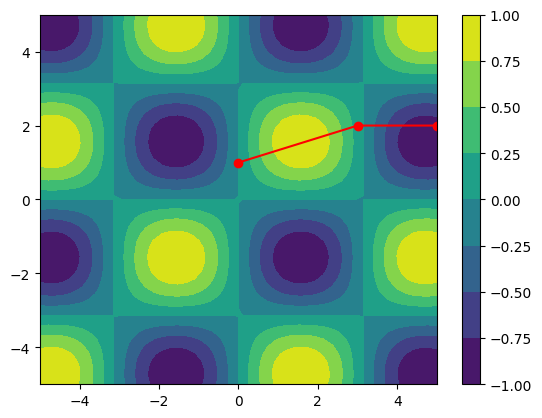

In [ ]:
xx = jnp.linspace(-5, 5, 50)
yy = jnp.linspace(-5,5, 50)
X, Y = jnp.meshgrid(xx, yy)
Z = jnp.sin(X) * jnp.sin(Y) #defining the function as Z

cs = plt.contourf(X,Y,Z) # takes the matrices and function
plt.colorbar(cs)
plt.plot([0,3,5],[1,2,2], "ro-")
# Result - 2D function, where color is the value of function at that point

In [ ]:
# function to visualize what the gradient is doing
def plot_optimization_2d(func, gd_path, gd_backtrack_path, title):
  # visualizing 2D functions
    x_vals = jnp.linspace(-5, 5, 50) # x values ->creating  1d grid between -5,5 of 50 points
    y_vals = jnp.linspace(-5, 5, 50) # similar 1D grid in Y direction
    X, Y = jnp.meshgrid(x_vals, y_vals) # create a grid with these values, X,Y are matrix, with X and Y coordinates respectively
    Z = jnp.array([[func(jnp.array([x, y])) for x in x_vals] for y in y_vals]) # Z is a function
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    cs = axs[0].contourf(X, Y, Z, levels=50, cmap="viridis")
    plt.colorbar(cs)
    axs[0].contour(X, Y, Z, colors="white")

    gd_path = jnp.array(gd_path)

    axs[0].plot(gd_path[:, 0], gd_path[:, 1], "r.-", label="GD")

    if gd_backtrack_path != []:
        gd_backtrack_path = jnp.array(gd_backtrack_path)
        axs[0].plot(
            gd_backtrack_path[:, 0],
            gd_backtrack_path[:, 1],
            ".-",
            color="orange",
            label="GD + backtracking",
        )
    axs[0].set_title(title)
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")
    axs[0].set_ylim([-5, 5])
    axs[0].set_xlim([-5, 5])
    axs[0].legend()

    axs[1].semilogy([func(x) for x in gd_path], "ro-", label="GD")
    axs[1].semilogy(
        [func(x) for x in gd_backtrack_path],
        "o-",
        color="orange",
        label="GD + backtracking",
    )
    axs[1].legend()
    plt.tight_layout()

## Defining Benchmark Functions

### 1. Rastrigin Function

The Rastrigin function is a **non-convex** and **multi-modal** function often used as a test for optimization algorithms.
It is defined as:

$$
f(x) = 10 n + \sum_{i=1}^n \left( x_i^2 - 10 \cos(2 \pi x_i) \right)
$$

with multiple local minima.

### 2. Ackley Function

The Ackley function is another **non-convex** function commonly used in optimization, given by:

$$
f(x) = -20 \exp \left( -0.2 \sqrt{\frac{1}{n} \sum_{i=1}^n x_i^2} \right) - \exp \left( \frac{1}{n} \sum_{i=1}^n \cos(2 \pi x_i) \right) + 20 + e
$$

### 3. Quadratic Function

The Quadratic function is **convex** and is defined as:

$$
f(x) = \frac{1}{2} x^T A x + b^T x + c
$$


In [ ]:
# Define the benchmark functions


# 1. Rastrigin function
@jax.jit
def rastrigin(x):
    return 10 * x.size + jnp.sum(x**2 - 10 * jnp.cos(2 * jnp.pi * x)) + 1e-10


# 2. Ackley function
@jax.jit
def ackley(x):
    a = 20
    b = 0.2
    c = 2 * jnp.pi
    sum1 = jnp.sum(x**2)
    sum2 = jnp.sum(jnp.cos(c * x))
    return (
        -a * jnp.exp(-b * jnp.sqrt(sum1 / x.size))
        - jnp.exp(sum2 / x.size)
        + a
        + jnp.exp(1)
    )


# 3. Quadratic function
quadratic_A = jnp.array([[3.0, 0.5], [0.5, 1.0]])
quadratic_b = jnp.array([-1.0, 2.0])
quadratic_c = jnp.dot(quadratic_b, jnp.linalg.solve(quadratic_A, quadratic_b)) / 2


@jax.jit
def quadratic(x):
    return (
        0.5 * jnp.dot(x.T, jnp.dot(quadratic_A, x))
        + jnp.dot(quadratic_b, x)
        + quadratic_c
    )

## Optimization Algorithms

### Gradient Descent

Gradient Descent is an iterative optimization algorithm defined by:

$$
x_{k+1} = x_k - \eta \nabla f(x_k)
$$

where $ \eta $ is the learning rate.


In [ ]:
# Calculate gradient descent with the given parameters
# grad_fucn = function we need to optimize
# x0 = initial value of our iterative algo
# lr = learning rate/step size
# tol = diff between 2 iterations, the convergence value
# max_iter = maximum number of iterations
"""
grad_func is the gradient of the objective function, not the objective function itself.
It should take x as input and return ∇f(x).
"""
def gradient_descent(grad_func, x0, lr=0.01, tol=1e-6, max_iter=1000):
  x = x0
  # to save path of all the points we pass
  path = [x]
  for _ in range(max_iter):  #_ character iteration, because here we don't need the iteration value
    grad_val = grad_func(x) # value of gradient function evaluated at x
    x = x - lr * grad_val
    path.append(x)
    # if the update is too small we stop,
    # we are controlling the norm of the gradient
    # if a point is minima then gradient is 0
    # if 2D or nD if the norm of the gradient is 0, then we are at minima
    if jnp.linalg.norm(grad_val) < tol:
      break

  return x, path


### Gradient Descent with Backtracking Line Search

Backtracking line search modifies the learning rate $ \eta $ to ensure sufficient decrease.

The key idea is to start with an initial step size and iteratively reduce it until a sufficient decrease condition is met. Specifically, the backtracking process adjusts the step size tt based on the Armijo condition:

$$
f(x - t \nabla f(x)) \leq f(x) - \alpha t \|\nabla f(x)\|^2
$$

where:

- $ f(x) $ is the objective function,
- $ \nabla f(x) $ is the gradient of $ f $ at $ x $,
- $ t $ is the step size (or learning rate) that we are adapting,
- $ \alpha \in (0, 0.5) $ is a parameter controlling the required decrease,
- $ \|\nabla f(x)\|^2 $ represents the squared norm of the gradient, quantifying how steep the descent is at $ x $.

The algorithm typically starts with an initial step size $ t = 1 $ and iteratively reduces it by multiplying it with a factor $ \beta \in (0, 1) $ (often $ \beta = 0.8 $), until the sufficient decrease condition is satisfied. The process can be summarized as follows:

1. **Initialize** $ t = 1 $.
2. **While** $ f(x - t \nabla f(x)) > f(x) - \alpha t \|\nabla f(x)\|^2 $:
   - Update $ t = \beta t $.
3. **Return** the adjusted step size $ t $.


here the lr won't be a fixed number, we update it everytime using backtracking


In [ ]:
def gradient_descent_backtracking(
    func, grad_func, x0, alpha=0.3, beta=0.8, tol=1e-6, max_iter=100
):
    # SOLUTION-BEGIN
    x = x0
    path = [x]  # for visualization purposes only
    for _ in range(max_iter):
        grad_val = grad_func(x)
        t = 1.0
        # Backtracking loop
        while func(x - t * grad_val) > func(x) - alpha * t * jnp.dot(
            grad_val, grad_val
        ):
            t *= beta
        x = x - t * grad_val
        path.append(x)
        if jnp.linalg.norm(grad_val) < tol:
            break
    # SOLUTION-END
    return x, path

### Exact Line Search for Quadratic Function

Exact line search minimizes the quadratic function
$$f(\boldsymbol x) = \frac{1}{2} \boldsymbol x^T A \boldsymbol x + \boldsymbol b^T \boldsymbol x + c $$
in each iteration by solving for the optimal step size $ t^* $ as:

$$
t^* = \frac{\nabla f(\boldsymbol x)^T \nabla f(\boldsymbol x)}{\nabla f(\boldsymbol x)^T A \nabla f(\boldsymbol x)}
$$

Indeed, at iteration $k$, we want to minimize the (univariate) function $g$

\begin{align*}
g(t) = f\big(\boldsymbol x^k + t \boldsymbol s^{k}\big) = \frac12 \big(\boldsymbol x^k + t \boldsymbol s^{k}\big)^T A \big(\boldsymbol x^k + t \boldsymbol s^{k}\big) + \boldsymbol b^T \big(\boldsymbol x^k + t \boldsymbol s^{k}\big) + c\\
= \frac12 \big(\boldsymbol x^k\big)^T A \boldsymbol x^k + \frac12 t ^2 \big(\boldsymbol s^{k}\big)^T A \boldsymbol s^{k} + t \big( \boldsymbol s^k \big)^T A \boldsymbol x^{k} + \boldsymbol b^T \boldsymbol x^k + t \boldsymbol b^T \boldsymbol s^{k} + c \\
= f\big(\boldsymbol x^k \big) + \frac12 t ^2 \big(\boldsymbol s^{k}\big)^T A \boldsymbol s^{k}+ t \big( \boldsymbol s^k \big)^T A \boldsymbol x^{k} + t \big( \boldsymbol s^{k}\big)^T \boldsymbol b\\
= f\big(\boldsymbol x^k \big) + \frac12 t ^2 \big(\boldsymbol s^{k}\big)^T A \boldsymbol s^{k}+ t \big( \boldsymbol s^k \big)^T \Big[A \boldsymbol x^{k} + \boldsymbol b\Big]
\end{align*}

where $\boldsymbol s^k = -\nabla f(\boldsymbol x^k)$. Performing the derivative, we have

$$g'(t) = t \big(\boldsymbol s^{k}\big)^T A \boldsymbol s^{k} + \big( \boldsymbol s^k  \big)^T \Big[A \boldsymbol x^{k} + \boldsymbol b\Big]$$

But, by definition of $f$

$$\nabla f(\boldsymbol x^k) = A \boldsymbol x^k + \boldsymbol b$$

Thus,

$$g'(t) = t \big(\boldsymbol s^{k}\big)^T A \boldsymbol s^{k} + \big( \boldsymbol s^k  \big)^T \nabla f(\boldsymbol x^k)$$

By setting $g'(t^*) = 0$ we have

$$t^* = \frac{\nabla f(\boldsymbol x^k)^T \nabla f(\boldsymbol x^k)}{\nabla f(\boldsymbol x^k)^T A \nabla f(\boldsymbol x^k)}$$




*   If the function we are optimizing is a quadratic function ( above n dimensional generalization of parabola), then the optimal learning rate is given by t* (above).
*   



In [ ]:
# here we don't have gradient function, instead it's t*
def exact_line_search_quadratic(A, b, x0, tol=1e-6, max_iter=100):
  x = x0
  path = [x]
  for _ in range(max_iter):
    grad_val = jnp.dot(A, x )+ b # the gradient here instead of grad func
    # gradient is always a column vector
    lr = jnp.dot(grad_val, grad_val) / jnp.dot(grad_val, jnp.dot(A, grad_val))
    x = x - lr * grad_val
    path.append(x)
    if jnp.linalg.norm(grad_val) < tol:
      break
    return x, path


## Testing Optimization Algorithms

Let's test our gradient descent methods on the benchmark functions, and visualize the results.


Testing on Rastrigin function
Testing on Ackley function
Testing on Quadratic function


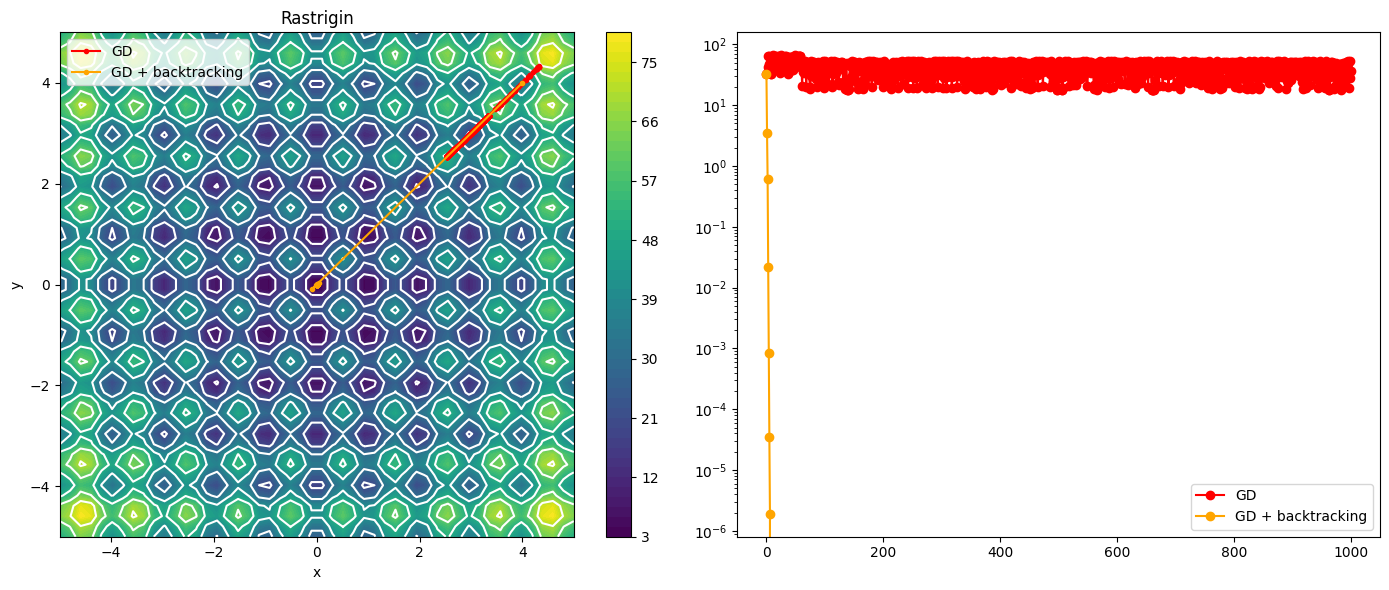

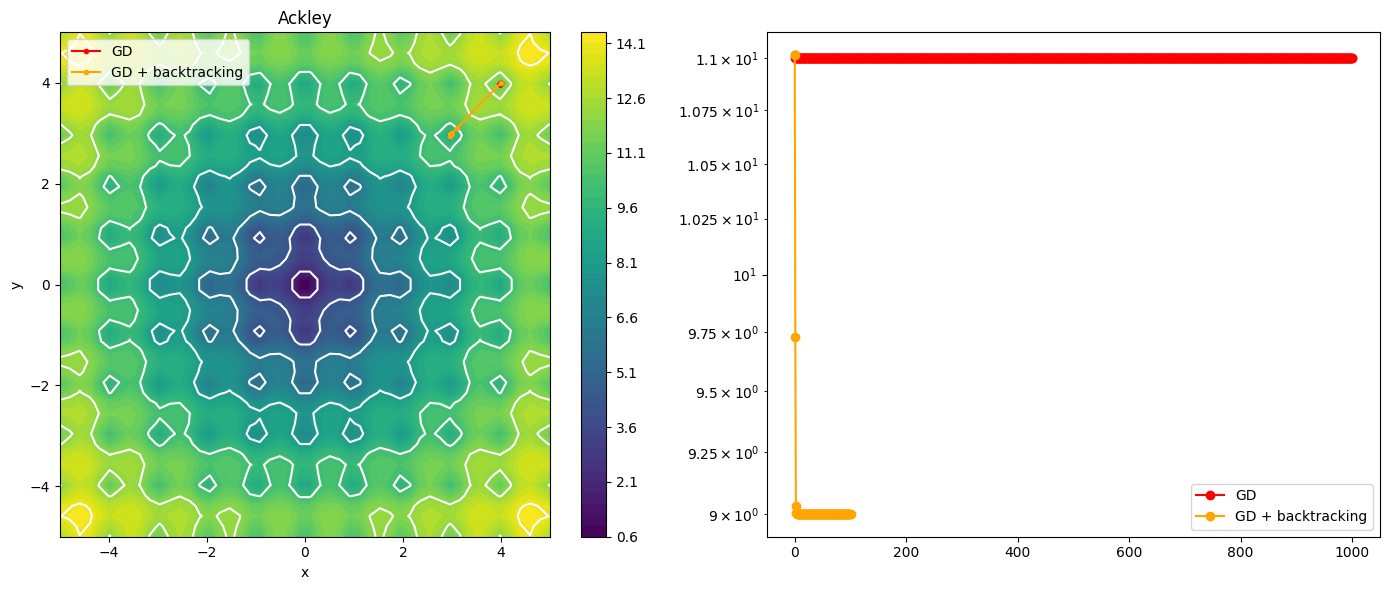

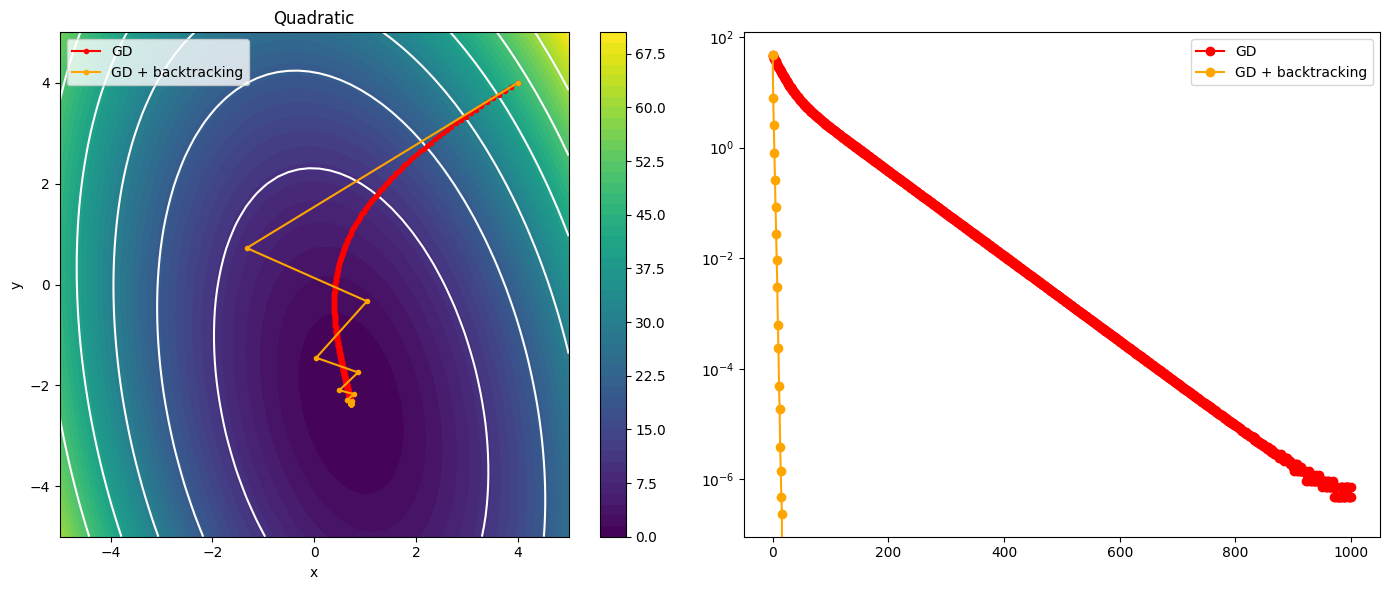

In [ ]:
x0 = jnp.array([4.0, 4.0])

test_functions = [
    (rastrigin, "Rastrigin"),
    (ackley, "Ackley"),
    (quadratic, "Quadratic"),
]

for func, name in test_functions:
    grad_func = jax.jit(jax.grad(func))
    print(f"Testing on {name} function")

    # Vanilla Gradient Descent
    x_gd, path_gd = gradient_descent(grad_func, x0)
    # Gradient descent with backtracking
    x_gd_bt, path_gd_bt = gradient_descent_backtracking(func, grad_func, x0)

    plot_optimization_2d(func, path_gd, path_gd_bt, title=f"{name}")

### Exact Line Search on Quadratic Function

Using exact line search, we aim to find the optimal path for the **Quadratic function**. This method is specific to quadratic functions and will only be applied to this case.


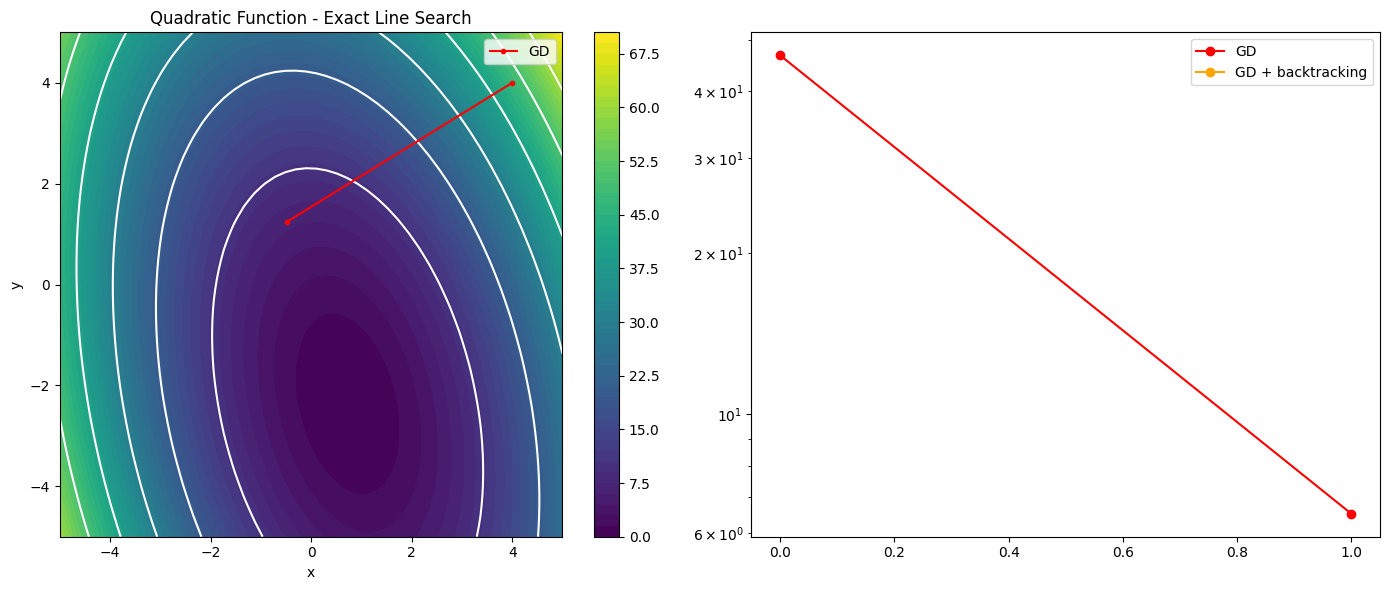

In [ ]:
x_exact, path_exact = exact_line_search_quadratic(quadratic_A, quadratic_b, x0)
plot_optimization_2d(
    quadratic, path_exact, [], title="Quadratic Function - Exact Line Search"
)